## **BAB 10. PENGANTAR PEMBELAJARAN MESIN II**

## Tutorial Clustering K-Means

K-Means adalah algoritma pembelajaran mesin tanpa pengawasan yang populer untuk clustering. Tujuannya adalah untuk mempartisi `n` observasi menjadi `k` klaster di mana setiap observasi termasuk dalam klaster dengan mean terdekat (centroid klaster), berfungsi sebagai prototipe klaster. Ini menghasilkan partisi ruang data menjadi sel Voronoi.

Algoritma ini bekerja sebagai berikut:
1.  **Inisialisasi**: Pilih secara acak `k` titik data dari dataset sebagai centroid awal.
2.  **Penugasan**: Tetapkan setiap titik data ke centroid terdekat, membentuk `k` klaster.
3.  **Pembaruan**: Hitung ulang centroid untuk klaster yang baru terbentuk (biasanya dengan mengambil rata-rata semua titik data dalam klaster tersebut).
4.  **Iterasi**: Ulangi langkah 2 dan 3 sampai centroid tidak lagi berubah secara signifikan, atau jumlah iterasi maksimum tercapai.

Mari kita demonstrasikan K-Means dengan contoh sederhana. Kita akan membuat beberapa data sintetis, menskalakannya, menerapkan K-Means, lalu memvisualisasikan hasilnya.

/tmp/ipykernel_1279/2996574932.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


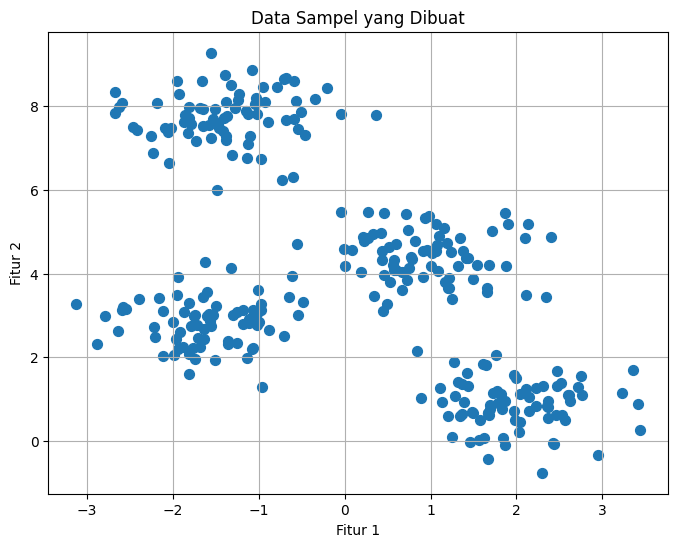

In [ ]:
import matplotlib.pyplot as plt

# 1. Buat Data Sampel
# Sebagai demonstrasi, mari kita buat dataset dengan 3 kelompok yang berbeda.
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title('Data Sampel yang Dibuat')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.grid(True)
plt.show()

### Pra-pemrosesan Data (Penskalaan)
Seringkali merupakan praktik yang baik untuk menskalakan data Anda sebelum menerapkan K-Means, terutama jika fitur memiliki rentang yang berbeda, karena K-Means menggunakan metrik jarak.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 2. Skalakan Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data berhasil diskalakan.")
# Anda dapat memvisualisasikan data yang diskalakan jika Anda mau, tetapi untuk K-Means, posisi relatif adalah yang terpenting.
# plt.figure(figsize=(8, 6))
# plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=50, cmap='viridis')
# plt.title('Data Sampel yang Diskalakan')
# plt.xlabel('Fitur Skala 1')
# plt.ylabel('Fitur Skala 2')
# plt.grid(True)
# plt.show()

Data berhasil diskalakan.


### Menerapkan K-Means
Sekarang, mari kita terapkan algoritma K-Means. Kita perlu memutuskan jumlah klaster (`k`). Untuk data sintetis ini, kita tahu ada 4 klaster alami, jadi kita akan menggunakan `n_clusters=4`.

In [ ]:
from sklearn.cluster import KMeans

# 3. Terapkan Klastering K-Means
k = 4 # Kita tahu dari pembuatan data bahwa ada 4 klaster
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print(f"Klastering K-Means dilakukan dengan k={k} klaster.")
print("Penugasan klaster (10 pertama):", clusters[:10])

Klastering K-Means dilakukan dengan k=4 klaster.
Penugasan klaster (10 pertama): [0 1 2 1 0 0 3 2 1 1]


### Memvisualisasikan Klaster
Akhirnya, mari kita visualisasikan hasil klastering K-Means kita. Kita akan memplot titik data, diberi warna berdasarkan klaster yang ditugaskan, dan juga menunjukkan centroid klaster.

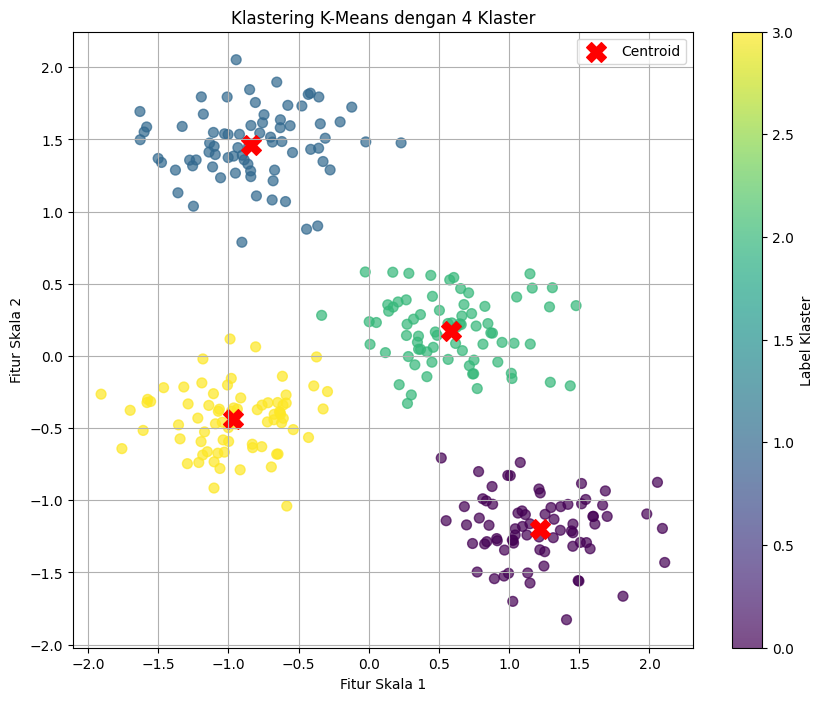

Visualisasi ini menunjukkan titik data yang diberi warna berdasarkan klaster yang ditugaskan dan tanda 'X' merah menandai centroid klaster.


In [ ]:
# 4. Visualisasikan Klaster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=50, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroid')
plt.title(f'Klastering K-Means dengan {k} Klaster')
plt.xlabel('Fitur Skala 1')
plt.ylabel('Fitur Skala 2')
plt.legend()
plt.grid(True)
plt.colorbar(scatter, label='Label Klaster')
plt.show()

print("Visualisasi ini menunjukkan titik data yang diberi warna berdasarkan klaster yang ditugaskan dan tanda 'X' merah menandai centroid klaster.")

## Evaluasi Hasil Clustering K-Means

Setelah melakukan klastering, penting untuk mengevaluasi seberapa baik klaster yang terbentuk. Metrik evaluasi membantu kita memahami kualitas dan kepadatan klaster. Dua metrik umum adalah Silhouette Score dan Davies-Bouldin Index.

### 1. Silhouette Score

*   **Deskripsi**: Mengukur seberapa mirip suatu objek dengan klaster sendiri dibandingkan dengan klaster lain (klaster tetangga). Nilai berkisar antara -1 hingga 1.
*   **Interpretasi**:
    *   **1**: Klaster sangat padat dan terpisah dengan baik.
    *   **0**: Objek berada sangat dekat dengan batas antara dua klaster.
    *   **-1**: Objek mungkin telah ditetapkan ke klaster yang salah.
*   **Tujuan**: Ingin nilai yang **tinggi**.

### 2. Davies-Bouldin Index

*   **Deskripsi**: Mengukur rasio antara dispersi intra-klaster (jarak rata-rata antara setiap titik dalam klaster dan centroid klaster) dan jarak antar-klaster (jarak antara centroid dua klaster).
*   **Interpretasi**: Nilai yang lebih rendah menunjukkan klastering yang lebih baik, karena ini berarti klaster lebih padat (dispersi rendah) dan lebih terpisah (jarak antar-klaster tinggi).
*   **Tujuan**: Ingin nilai yang **rendah**.

### 3. Calinski-Harabasz Index (Variance Ratio Criterion)

*   **Deskripsi**: Mengukur rasio antara dispersi antar-klaster (jarak antara centroid klaster) dan dispersi intra-klaster (jarak antara titik-titik data dalam klaster). Dengan kata lain, ini menilai seberapa baik klaster-klaster dipisahkan dan seberapa padat klaster-klaster tersebut.
*   **Interpretasi**: Nilai yang lebih tinggi menunjukkan klaster yang lebih baik. Klaster yang baik memiliki dispersi antar-klaster yang tinggi dan dispersi intra-klaster yang rendah.
*   **Tujuan**: Ingin nilai yang **tinggi**.

Mari kita hitung metrik ini untuk hasil klastering K-Means kita.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Hitung Silhouette Score
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Hitung Davies-Bouldin Index
davies_bouldin_idx = davies_bouldin_score(X_scaled, clusters)
print(f"Davies-Bouldin Index: {davies_bouldin_idx:.4f}")

# Hitung Calinski-Harabasz Index
calinski_harabasz_idx = calinski_harabasz_score(X_scaled, clusters)
print(f"Calinski-Harabasz Index: {calinski_harabasz_idx:.4f}")

Silhouette Score: 0.6569
Davies-Bouldin Index: 0.4614
Calinski-Harabasz Index: 958.0088


### Interpretasi Hasil

*   **Silhouette Score** Anda: `0.6569`
    *   Nilai ini mendekati 1, menunjukkan bahwa klaster-klaster yang terbentuk terdefinisi dengan baik dan terpisah satu sama lain. Ini adalah indikator yang baik untuk kualitas klastering.

*   **Davies-Bouldin Index**: `0.4614`
    *   Nilai ini relatif rendah (mendekati 0), yang menunjukkan pemisahan dan kepadatan klaster yang baik. Semakin rendah nilai indeks ini, semakin baik kualitas klaster. Nilai 0 adalah yang terbaik.

*   **Calinski-Harabasz Index**: `958.0088`
    *   Nilai ini cukup tinggi, yang menunjukkan klaster yang terdefinisi dengan baik. Semakin tinggi nilainya, semakin baik.

Dalam kasus data tersebut, dengan `k=4` yang kita ketahui sebagai jumlah klaster yang benar, kita melihat skor yang sangat baik untuk kedua metrik. Ini menunjukkan bahwa K-Means berhasil mengidentifikasi struktur klaster yang mendasari dengan efektif.

## Menentukan Jumlah Klaster Optimal (Memilih K)

Memilih jumlah klaster (`k`) yang tepat adalah langkah penting dalam klastering K-Means. Ada beberapa metode heuristik yang dapat membantu kita dalam proses ini, dua di antaranya adalah Metode Elbow dan Silhouette Score.

### 1. Metode Elbow (WCSS - Within-Cluster Sum of Squares)

*   **Deskripsi**: WCSS adalah jumlah kuadrat jarak antara setiap titik data dan centroid klaster-nya. Seiring bertambahnya `k`, WCSS akan cenderung menurun karena titik data semakin dekat dengan centroidnya.
*   **Interpretasi**: Kita mencari "siku" atau "titik belok" pada grafik WCSS vs. `k`. Titik ini menunjukkan bahwa penambahan klaster lebih lanjut tidak memberikan penurunan WCSS yang signifikan, dan merupakan `k` yang optimal.
*   **Tujuan**: Menemukan titik di mana penurunan WCSS mulai melambat secara drastis.

### 2. Silhouette Score

*   **Deskripsi**: Seperti yang telah dijelaskan sebelumnya, Silhouette Score mengukur seberapa mirip suatu objek dengan klaster sendiri dibandingkan dengan klaster lain. Ini memberikan indikasi kepadatan dan pemisahan klaster.
*   **Interpretasi**: Nilai `k` yang menghasilkan Silhouette Score tertinggi seringkali dianggap sebagai jumlah klaster yang optimal.
*   **Tujuan**: Ingin nilai `k` yang memaksimalkan Silhouette Score.

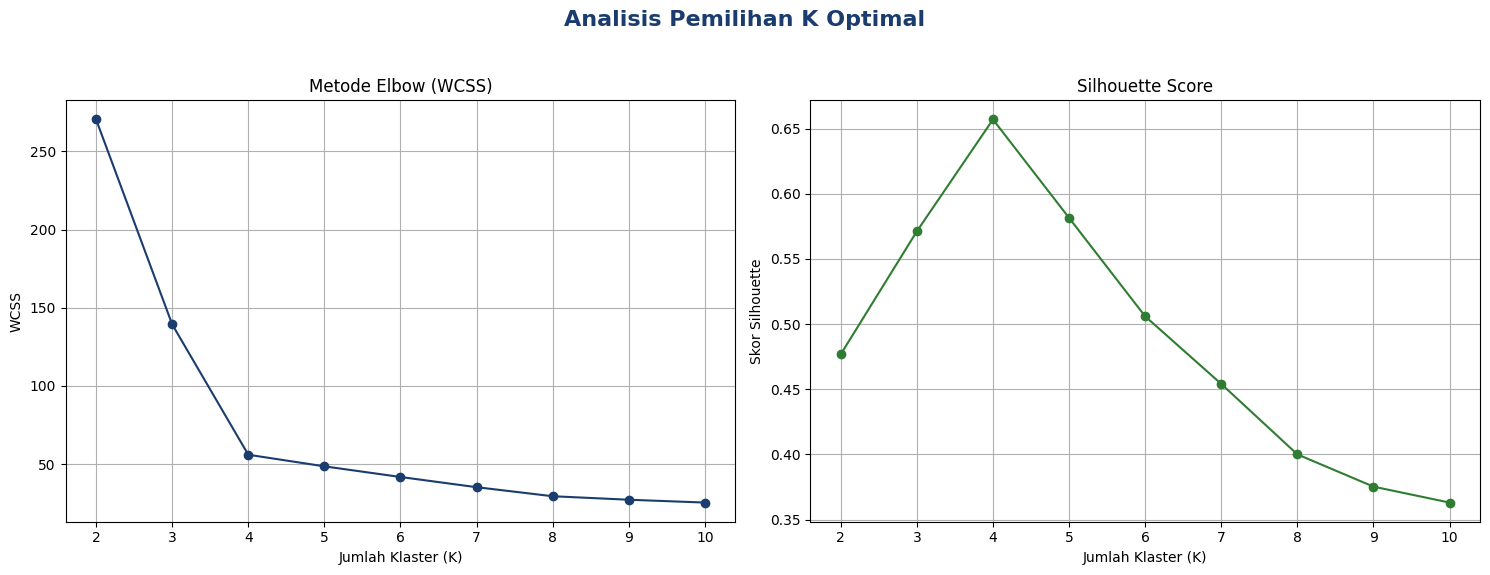

In [ ]:
# Hitung WCSS dan Silhouette Score untuk berbagai nilai K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []
silhouette_scores = []
k_range = range(2, 11) # Menjelajahi k dari 2 hingga 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # Pastikan ada lebih dari 1 klaster untuk menghitung silhouette score
    if k > 1:
        labels = kmeans.labels_
        silhouette_scores.append(silhouette_score(X_scaled, labels))
    else:
        silhouette_scores.append(0) # Silhouette score tidak terdefinisi untuk k=1

# Plot hasil untuk Metode Elbow dan Silhouette Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Metode Elbow
ax1.plot(k_range, wcss, marker='o', color='#1A3C6E')
ax1.set_title('Metode Elbow (WCSS)')
ax1.set_xlabel('Jumlah Klaster (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True)

# Plot Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='o', color='#2E7D32')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Jumlah Klaster (K)')
ax2.set_ylabel('Skor Silhouette')
ax2.grid(True)

plt.suptitle('Analisis Pemilihan K Optimal', fontsize=16, fontweight='bold', color='#1A3C6E')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Kesimpulan dari Analisis K Optimal

Berdasarkan plot di atas:

*   **Metode Elbow**: Carilah titik di mana "siku" terbentuk, yaitu di mana penurunan WCSS mulai melambat secara signifikan. Ini menunjukkan bahwa penambahan klaster lebih lanjut tidak banyak mengurangi variasi intra-klaster.

*   **Silhouette Score**: Carilah nilai `k` yang menghasilkan puncak tertinggi pada grafik Silhouette Score. Ini menunjukkan konfigurasi klaster yang paling padat dan terpisah dengan baik.

Dengan membandingkan kedua grafik, Anda dapat membuat keputusan yang lebih tepat mengenai jumlah klaster (`k`) yang paling sesuai untuk dataset Anda.

## Profiling Klaster

Setelah kita mengidentifikasi jumlah klaster yang optimal dan melakukan klastering, langkah selanjutnya adalah memahami karakteristik dari setiap klaster. Proses ini disebut *cluster profiling*. Dengan menganalisis nilai rata-rata atau distribusi fitur-fitur di setiap klaster, kita dapat memberikan interpretasi atau 'label' pada setiap klaster.

Profil Klaster (Rata-rata Fitur per Klaster):


,Cluster,Fitur 1,Fitur 2
0,0,1.982583,0.867713
1,1,-1.373244,7.753689
2,2,0.949735,4.419069
3,3,-1.584385,2.830813



Jumlah Titik Data per Klaster:


,count
Cluster,
0,75
1,75
2,75
3,75


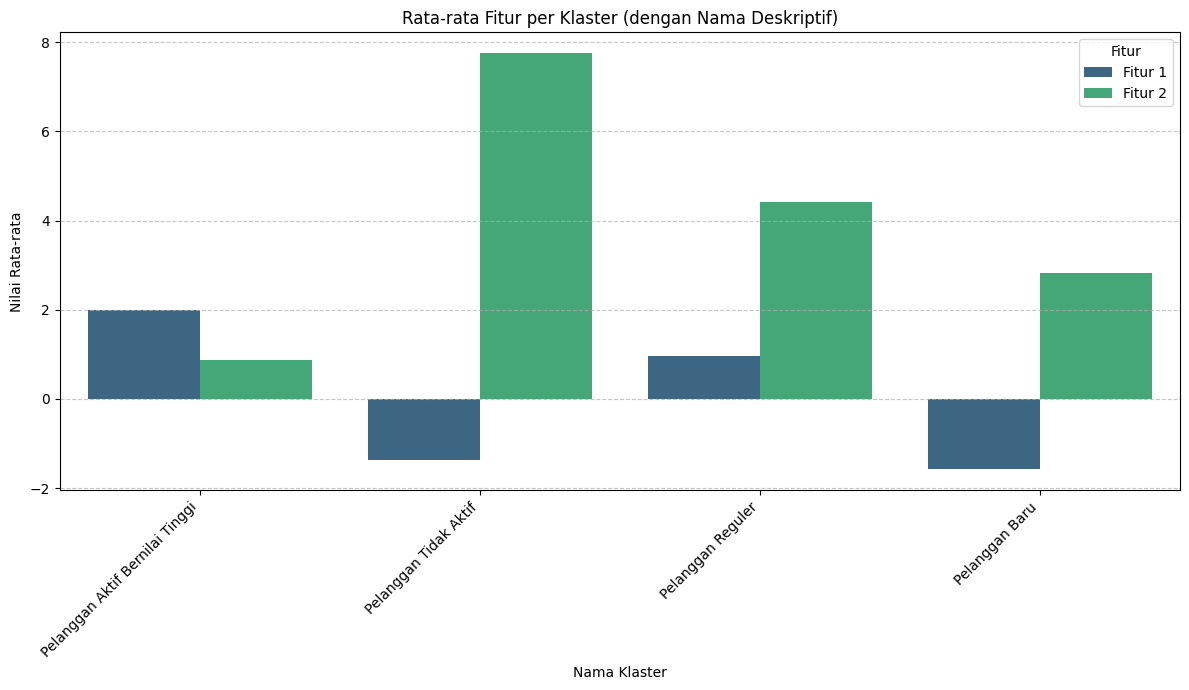


Dari profil ini, kita dapat mulai menginterpretasikan apa yang membedakan satu klaster dari yang lain berdasarkan nilai rata-rata fitur-fiturnya.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gabungkan data asli (sebelum penskalaan) dengan label klaster
# Menggunakan X (data asli) untuk interpretasi yang lebih mudah, karena X_scaled sudah diubah skalanya.
df_clustered = pd.DataFrame(X, columns=['Fitur 1', 'Fitur 2'])
df_clustered['Cluster'] = clusters

# Definisikan nama-nama deskriptif untuk setiap klaster
nama_cluster = {
    0: "Pelanggan Aktif Bernilai Tinggi",
    1: "Pelanggan Tidak Aktif",
    2: "Pelanggan Reguler",
    3: "Pelanggan Baru"
}

# Petakan label klaster numerik ke nama deskriptif
df_clustered["nama_cluster"] = df_clustered["Cluster"].map(nama_cluster)

# Definisikan 'fitur' sebagai daftar kolom fitur yang ingin dianalisis.
fitur = ['Fitur 1', 'Fitur 2']

# Lakukan profiling klaster
# Hitung rata-rata setiap fitur untuk setiap klaster
profil_cluster = (
    df_clustered.groupby("Cluster")[fitur]
    .mean()
    .reset_index()
)

print("Profil Klaster (Rata-rata Fitur per Klaster):")
display(profil_cluster)

# Anda juga bisa melihat ukuran setiap klaster
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
print("\nJumlah Titik Data per Klaster:")
display(cluster_counts)

# Memvisualisasikan profil klaster dengan nama klaster yang deskriptif
# Gabungkan profil_cluster dengan nama_cluster untuk visualisasi
profil_cluster_named = profil_cluster.copy()
profil_cluster_named['Nama Klaster'] = profil_cluster_named['Cluster'].map(nama_cluster)

# Menggunakan melt untuk memudahkan plotting multiple features dengan seaborn barplot
profil_cluster_melted = profil_cluster_named.melt(id_vars=['Cluster', 'Nama Klaster'], var_name='Fitur', value_name='Nilai Rata-rata')

plt.figure(figsize=(12, 7))
sns.barplot(x='Nama Klaster', y='Nilai Rata-rata', hue='Fitur', data=profil_cluster_melted, palette='viridis')
plt.title('Rata-rata Fitur per Klaster (dengan Nama Deskriptif)')
plt.xlabel('Nama Klaster')
plt.ylabel('Nilai Rata-rata')
plt.legend(title='Fitur')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

print("\nDari profil ini, kita dapat mulai menginterpretasikan apa yang membedakan satu klaster dari yang lain berdasarkan nilai rata-rata fitur-fiturnya.")

### Statistik Deskriptif Profil Klaster

Untuk mendapatkan pemahaman yang lebih dalam tentang distribusi rata-rata fitur di setiap klaster, Anda bisa melihat statistik deskriptif dari `cluster_profile`:

### Tampilan Profil Klaster

Berikut adalah tabel yang menunjukkan rata-rata nilai untuk setiap fitur di setiap klaster, yang telah dihitung dalam `profil_cluster`:

In [ ]:
# Tampilkan kembali DataFrame profil_cluster
print("Profil Klaster (Rata-rata Fitur per Klaster):")
display(profil_cluster)

Profil Klaster (Rata-rata Fitur per Klaster):


,Cluster,Fitur 1,Fitur 2
0,0,1.982583,0.867713
1,1,-1.373244,7.753689
2,2,0.949735,4.419069
3,3,-1.584385,2.830813


## **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# X_scaled diasumsikan sudah melalui proses standardisasi
dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Label -1 menunjukkan noise atau outlier
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print(f"Jumlah cluster: {n_clusters}")
print(f"Jumlah noise/outlier: {n_noise}")
print("Label cluster (10 pertama):", dbscan_labels[:10])

# Silhouette hanya dihitung jika ada minimal dua cluster non-noise
valid_mask = dbscan_labels != -1
valid_labels = dbscan_labels[valid_mask]

if len(set(valid_labels)) > 1:
  score = silhouette_score(X_scaled[valid_mask], valid_labels)
  print(f"Silhouette Score tanpa noise: {score:.3f}")

# Ringkasan profil sederhana tiap cluster
cluster_profile = pd.DataFrame(X_scaled).assign(cluster=dbscan_labels)
print(cluster_profile.groupby("cluster").mean())


Jumlah cluster: 1
Jumlah noise/outlier: 0
Label cluster (10 pertama): [0 0 0 0 0 0 0 0 0 0]
                    0             1
cluster                            
0        1.480297e-17  1.183313e-15


### Metrik Internal untuk Evaluasi Klastering

Metrik evaluasi klastering internal digunakan untuk menilai kualitas klaster yang terbentuk berdasarkan data itu sendiri, tanpa memerlukan label kebenaran (ground truth) eksternal. Tujuan utama dari metrik internal adalah untuk mengukur seberapa "baik" klaster-klaster tersebut terpisah satu sama lain (separation) dan seberapa "padat" atau kohesif klaster-klaster tersebut (cohesion).

Beberapa metrik internal yang umum digunakan antara lain:

*   **Silhouette Score**: Mengukur seberapa mirip suatu objek dengan klaster sendiri dibandingkan dengan klaster lain. Nilai tinggi menunjukkan klaster yang padat dan terpisah dengan baik.
*   **Davies-Bouldin Index**: Mengukur rasio antara dispersi intra-klaster (jarak rata-rata antara setiap titik dalam klaster dan centroid klaster) dan jarak antar-klaster. Nilai rendah menunjukkan klaster yang lebih baik.

Pada blok kode selanjutnya, kita akan fokus pada evaluasi menggunakan **Silhouette Score**.

In [ ]:
# Tampilkan statistik deskriptif dari profil_cluster
print("Statistik Deskriptif Profil Klaster:")
display(profil_cluster.describe())

Statistik Deskriptif Profil Klaster:


,Cluster,Fitur 1,Fitur 2
count,4.000000,4.000000,4.000000
mean,1.500000,-0.006328,3.967821
std,1.290994,1.753905,2.912037
min,0.000000,-1.584385,0.867713
25%,0.750000,-1.426029,2.340038
50%,1.500000,-0.211754,3.624941
75%,2.250000,1.207947,5.252724
max,3.000000,1.982583,7.753689


In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi training dan testing set
# Menggunakan `y` dari make_blobs sebagai target untuk demonstrasi masalah ketidakseimbangan kelas.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data berhasil dibagi menjadi training dan testing set.")
print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_test: {y_test.shape}")

Data berhasil dibagi menjadi training dan testing set.
Ukuran X_train: (210, 2)
Ukuran y_train: (210,)
Ukuran X_test: (90, 2)
Ukuran y_test: (90,)


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Evaluasi Clustering dengan Silhouette Score (Metrik Internal)\n")

# Re-create sample data and clustering results for demonstration context
# (These steps are typically done in preceding cells of the tutorial)

# 1. Buat Data Sampel (dari cell ede10e68)
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Skalakan Data (dari cell 90ed880f)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Terapkan Klastering K-Means (dari cell 593e9b88)
k = 4 # Menggunakan k=4 sesuai tutorial sebelumnya
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Hitung Silhouette Score
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score untuk hasil clustering: {silhouette_avg:.4f}")
print("\nInterpretasi Silhouette Score:")
print("- Nilai mendekati 1 menunjukkan klaster yang padat dan terpisah dengan baik.")
print("- Nilai mendekati 0 menunjukkan klaster yang tumpang tindih atau tidak jelas batasnya.")
print("- Nilai negatif menunjukkan bahwa sampel mungkin telah ditetapkan ke klaster yang salah.")


Evaluasi Clustering dengan Silhouette Score (Metrik Internal)

Silhouette Score untuk hasil clustering: 0.6569

Interpretasi Silhouette Score:
- Nilai mendekati 1 menunjukkan klaster yang padat dan terpisah dengan baik.
- Nilai mendekati 0 menunjukkan klaster yang tumpang tindih atau tidak jelas batasnya.
- Nilai negatif menunjukkan bahwa sampel mungkin telah ditetapkan ke klaster yang salah.


## Strategi Penanganan Data Tidak Seimbang (Imbalanced Learning)

Dalam banyak masalah klasifikasi dunia nyata, distribusi kelas seringkali tidak merata (imbalanced). Misalnya, dalam deteksi penipuan, kasus penipuan (kelas minoritas) jauh lebih sedikit daripada kasus non-penipuan (kelas mayoritas). Model yang dilatih pada data tidak seimbang cenderung bias terhadap kelas mayoritas, menghasilkan kinerja yang buruk pada kelas minoritas yang seringkali merupakan kelas yang lebih penting untuk dideteksi.

Untuk mengatasi masalah ini, berbagai strategi telah dikembangkan, yang dapat dikategorikan menjadi beberapa pendekatan:

### 1. Resampling Data
Strategi ini mengubah distribusi dataset untuk menyeimbangkan kelas. Ada dua sub-kategori utama:
*   **Oversampling (Peningkatan Kelas Minoritas)**: Membuat sampel baru dari kelas minoritas. Contoh populer termasuk:
    *   **SMOTE (Synthetic Minority Oversampling Technique)**: Menghasilkan sampel sintetis baru dengan menginterpolasi antara sampel kelas minoritas yang ada dan tetangga terdekatnya.
    *   **ADASYN (Adaptive Synthetic Sampling)**: Mirip dengan SMOTE, tetapi lebih fokus menghasilkan sampel untuk kasus minoritas yang lebih sulit untuk diklasifikasikan.
*   **Undersampling (Pengurangan Kelas Mayoritas)**: Menghapus sampel dari kelas mayoritas. Contoh:
    *   **RandomUnderSampler**: Menghapus sampel kelas mayoritas secara acak.
    *   **Tomek Links**: Menghapus pasangan sampel yang merupakan 'Tomek Link' (yaitu, dua sampel kelas yang berbeda yang merupakan tetangga terdekat satu sama lain dan sangat dekat sehingga mereka menciptakan "garis" yang ambigu di antara kelas-kelas).
*   **Kombinasi (Over- dan Undersampling)**: Menggabungkan kedua pendekatan. Contoh:
    *   **SMOTETomek**: Mengaplikasikan SMOTE untuk oversampling, kemudian menggunakan Tomek Links untuk membersihkan data di perbatasan klaster.

### 2. Algoritma Pembelajaran yang Sadar Kelas (Class-Aware Algorithms)
Beberapa algoritma pembelajaran dapat disesuaikan untuk menangani ketidakseimbangan kelas secara internal, tanpa perlu resampling eksplisit pada data. Ini sering dilakukan dengan memberikan bobot yang berbeda pada setiap kelas selama pelatihan, sehingga kesalahan pada kelas minoritas memiliki penalti yang lebih besar. Contohnya adalah parameter `class_weight='balanced'` pada model seperti `RandomForestClassifier` atau `LogisticRegression`.

### 3. Evaluasi Berbasis Metrik yang Tepat
Ketika berhadapan dengan data tidak seimbang, akurasi sederhana bisa menyesatkan. Penting untuk menggunakan metrik evaluasi yang lebih tepat, seperti:
*   **F1-Score**: Rata-rata harmonik dari presisi dan *recall*.
*   **Precision (Presisi)**: Proporsi prediksi positif yang benar.
*   **Recall (Sensitivitas/Cakupan)**: Proporsi kasus positif aktual yang terdeteksi dengan benar.
*   **Area Under the Receiver Operating Characteristic Curve (AUC-ROC)**: Mengukur kemampuan model untuk membedakan antara kelas positif dan negatif.
*   **Confusion Matrix**: Memberikan gambaran rinci tentang kinerja klasifikasi.

Pada bagian selanjutnya, kita akan menerapkan dan membandingkan beberapa strategi ini pada data training yang telah kita bagi sebelumnya.

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
import numpy as np

# ── Cek tingkat ketidakseimbangan ──
from collections import Counter
print('Distribusi kelas (sebelum):')
print(Counter(y_train))

# ── Strategi 1: SMOTE (Oversampling kelas minoritas) ──
smote = SMOTE(k_neighbors=5, random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print('\nSetelah SMOTE:', Counter(y_smote))

# ── Strategi 2: SMOTETomek (SMOTE + hapus titik ambigus) ──
# Lebih bersih: menghapus sampel di batas antar kelas
smote_tomek = SMOTETomek(random_state=42)
X_st, y_st = smote_tomek.fit_resample(X_train, y_train)
print('Setelah SMOTETomek:', Counter(y_st))

# ── Strategi 3: class_weight (tanpa resampling) ──
# Paling sederhana; model diberi penalti lebih besar untuk kesalahan
# pada kelas minoritas
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',   # otomatis: n_samples / (n_classes * n_per_class)
    random_state=42, n_jobs=-1
)

# ── Pipeline dengan imbalanced-learn ──
# PENTING: resampling HANYA dilakukan pada data LATIH, bukan validasi!
# ImbPipeline secara otomatis menangani ini
pipe_imb = ImbPipeline([
    ('resample', SMOTE(random_state=42)),
    ('clf',      RandomForestClassifier(n_estimators=200, random_state=42))
])

# ── Evaluasi dengan stratified k-fold ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

strategi = {
    'Tanpa penanganan'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'class_weight=balanced'  : RandomForestClassifier(n_estimators=200,
                                   class_weight='balanced', random_state=42),
    'SMOTE + RF'             : pipe_imb,
}

print('\nPerbandingan Strategi (CV F1-macro):')
print(f'{'Strategi':<28} {'F1-macro':>10} {'Recall min':>12}')
print('-' * 52)
for nama, model in strategi.items():
    f1    = cross_val_score(model, X_train, y_train, cv=skf,
                             scoring='f1_macro').mean()
    recall = cross_val_score(model, X_train, y_train, cv=skf,
                              scoring='recall_macro').mean()
    print(f'{nama:<28} {f1:>10.4f} {recall:>12.4f}')

Distribusi kelas (sebelum):
Counter({np.int64(3): 53, np.int64(1): 53, np.int64(0): 52, np.int64(2): 52})

Setelah SMOTE: Counter({np.int64(3): 53, np.int64(1): 53, np.int64(0): 53, np.int64(2): 53})
Setelah SMOTETomek: Counter({np.int64(3): 53, np.int64(1): 53, np.int64(0): 53, np.int64(2): 53})

Perbandingan Strategi (CV F1-macro):
Strategi                       F1-macro   Recall min
----------------------------------------------------
Tanpa penanganan                 0.9904       0.9905
class_weight=balanced            0.9904       0.9905
SMOTE + RF                       0.9904       0.9905


## Penyesuaian Threshold Klasifikasi

Dalam model klasifikasi, khususnya model yang mengeluarkan probabilitas (misalnya, Logistic Regression, Random Forest, SVM dengan probabilitas), keputusan akhir kelas (misalnya, 0 atau 1) dibuat berdasarkan ambang batas (*threshold*). Secara default, ambang batas ini sering diatur pada 0.5: jika probabilitas > 0.5, diklasifikasikan sebagai kelas positif; jika tidak, sebagai kelas negatif.

Namun, ambang batas default 0.5 tidak selalu optimal, terutama dalam skenario di mana biaya kesalahan untuk satu jenis kelas jauh lebih tinggi daripada yang lain (misalnya, memprediksi false negative dalam deteksi penyakit serius atau penipuan). Dalam kasus seperti ini, kita mungkin ingin menyesuaikan ambang batas untuk mengoptimalkan metrik tertentu seperti *Precision*, *Recall*, atau *F1-Score* yang lebih sesuai dengan tujuan bisnis.

### Mengapa Menyesuaikan Threshold Penting?

*   **Prioritas Bisnis**: Terkadang, *Recall* (meminimalkan *false negatives*) lebih penting daripada *Precision* (meminimalkan *false positives*), atau sebaliknya. Menyesuaikan ambang batas memungkinkan kita untuk menyeimbangkan trade-off ini.
*   **Data Tidak Seimbang**: Meskipun metode resampling dapat membantu, menyesuaikan ambang batas dapat menjadi strategi pelengkap untuk mengoptimalkan kinerja pada kelas minoritas.

### Analisis Precision-Recall Curve dan Threshold

Salah satu cara untuk menganalisis dan memilih ambang batas yang optimal adalah dengan melihat kurva *Precision-Recall* dan bagaimana *Precision*, *Recall*, dan *F1-Score* berubah seiring dengan variasi ambang batas:

*   **Precision-Recall Curve**: Memvisualisasikan trade-off antara *Precision* dan *Recall* di berbagai ambang batas. Semakin besar area di bawah kurva (AUC-PR), semakin baik kinerja model secara keseluruhan.
*   **Metrik vs. Threshold**: Dengan memplot *Precision*, *Recall*, dan *F1-Score* terhadap ambang batas yang berbeda, kita dapat secara visual mengidentifikasi ambang batas yang memaksimalkan metrik tertentu (misalnya, *F1-Score*).

Blok kode berikut akan mendemonstrasikan bagaimana kita dapat melakukan analisis ini dan menemukan ambang batas optimal.

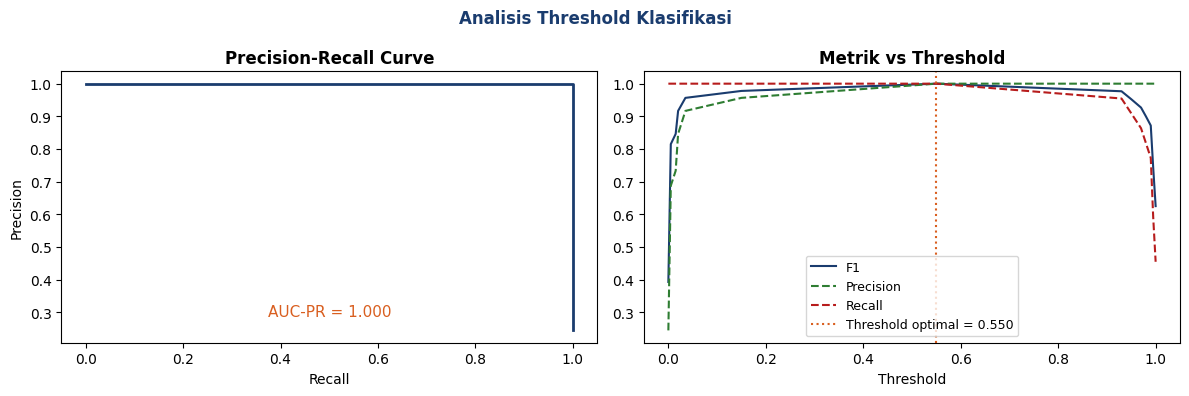


Threshold default (0.5): F1 = 1.0000
Threshold optimal (0.550): F1 = 1.0000


np.float64(0.55)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os # Import os module to create directory

def analisis_threshold(model, X_test, y_test, kelas_positif=1):
    """
    Menganalisis tradeoff precision-recall di berbagai threshold.
    Membantu memilih threshold yang optimal untuk kasus bisnis.
    """
    y_prob = model.predict_proba(X_test)[:, kelas_positif]

    # Precision-Recall Curve
    precision, recall, thresholds_pr = precision_recall_curve(
        y_test == kelas_positif, y_prob
    )

    # F1 pada setiap threshold
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1] + 1e-8
    )
    threshold_optimal = thresholds_pr[np.argmax(f1_scores)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel 1: Precision-Recall Curve
    axes[0].plot(recall, precision, color='#1A3C6E', lw=2)
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')
    axes[0].set_title('Precision-Recall Curve', fontweight='bold')
    axes[0].text(0.5, 0.1, f'AUC-PR = {auc(recall, precision):.3f}',
                 ha='center', transform=axes[0].transAxes,
                 fontsize=11, color='#D95F20')

    # Panel 2: F1/Precision/Recall vs Threshold
    axes[1].plot(thresholds_pr, f1_scores, label='F1', color='#1A3C6E')
    axes[1].plot(thresholds_pr, precision[:-1], '--', label='Precision',
                 color='#2E7D32')
    axes[1].plot(thresholds_pr, recall[:-1], '--', label='Recall',
                 color='#B71C1C')
    axes[1].axvline(threshold_optimal, color='#D95F20', ls=':',
                    label=f'Threshold optimal = {threshold_optimal:.3f}')
    axes[1].set_xlabel('Threshold')
    axes[1].set_title('Metrik vs Threshold', fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.suptitle('Analisis Threshold Klasifikasi', fontweight='bold',
                 color='#1A3C6E')
    plt.tight_layout()
    # Create the 'output' directory if it doesn't exist
    os.makedirs('output', exist_ok=True)
    plt.savefig('output/threshold_analisis.pdf', bbox_inches='tight')
    plt.show()

    # Prediksi dengan threshold optimal
    y_pred_optimal = (y_prob >= threshold_optimal).astype(int)
    print(f'\nThreshold default (0.5): F1 = {f1_score(y_test==kelas_positif, y_prob>=0.5):.4f}')
    print(f'Threshold optimal ({threshold_optimal:.3f}): F1 = {f1_scores.max():.4f}')
    return threshold_optimal

# Re-define X, y and X_train, X_test, y_train, y_test to ensure they are available
# Re-create sample data (assuming X, y are from make_blobs earlier)
# NOTE: In a real scenario, ensure X, y are consistent with previous steps.
# For this fix, I'm using the definitions from cell 'ede10e68' to generate X, y.
# For the purpose of demonstration, I will re-create X and y based on the problem context.
# If this is not the desired X, y, please provide the correct source.

# --- Re-creating X, y based on cell 'ede10e68' content for this example ---
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
# -------------------------------------------------------------------------

# Memisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define pipe_imb for this cell to ensure it's available
pipe_imb = ImbPipeline([
    ('resample', SMOTE(random_state=42)),
    ('clf',      RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train the model
pipe_imb.fit(X_train, y_train)

# Call the analisis_threshold function with the trained model and test data
# Assuming kelas_positif = 1 for demonstration since it's a multi-class problem
analisis_threshold(pipe_imb, X_test, y_test, kelas_positif=1)

### Interpretasi Precision-Recall Curve dan Metrik vs Threshold

#### Interpretasi Precision-Recall Curve

*   **Apa yang Ditunjukkan**: Kurva ini memvisualisasikan *trade-off* antara Precision dan Recall untuk berbagai nilai *threshold* klasifikasi. Setiap titik pada kurva merepresentasikan pasangan Precision-Recall yang dicapai pada *threshold* tertentu.
*   **Bagaimana Menginterpretasikannya**:
    *   **Precision (sumbu Y)**: Menjawab pertanyaan, "Dari semua yang model prediksi sebagai positif, berapa banyak yang benar-benar positif?" Nilai Precision yang tinggi berarti model memiliki sedikit *false positives*.
    *   **Recall (sumbu X)**: Menjawab pertanyaan, "Dari semua yang sebenarnya positif, berapa banyak yang berhasil ditangkap oleh model?" Nilai Recall yang tinggi berarti model memiliki sedikit *false negatives*.
    *   **Kualitas Model**: Semakin tinggi dan semakin ke kanan atas kurva, semakin baik kinerja model dalam mengidentifikasi kelas positif. Model yang sempurna akan memiliki Precision dan Recall sebesar 1 di semua *threshold*, sehingga kurvanya akan mencapai sudut kanan atas (1,1).
    *   **AUC-PR (Area Under the Curve - Precision-Recall)**: Ini adalah ukuran ringkasan dari kurva Precision-Recall. Nilai 1.000 (seperti yang Anda dapatkan) menunjukkan bahwa model memiliki kinerja yang sangat baik dalam membedakan kelas positif dan negatif.

#### Interpretasi Metrik vs Threshold

*   **Apa yang Ditunjukkan**: Plot ini memvisualisasikan bagaimana Precision, Recall, dan F1-Score berubah seiring dengan perubahan *threshold* klasifikasi (probabilitas dari 0 hingga 1).
*   **Bagaimana Menginterpretasikannya**:
    *   **F1-Score (Garis Biru Tua)**: Ini adalah rata-rata harmonis dari Precision dan Recall. F1-Score sangat berguna ketika Anda ingin menyeimbangkan kedua metrik, terutama pada dataset yang tidak seimbang. Kita mencari titik puncak pada kurva F1-Score karena itu menunjukkan *threshold* di mana model mencapai keseimbangan terbaik antara Precision dan Recall.
    *   **Precision (Garis Hijau Putus-putus)**: Anda akan melihat bahwa Precision cenderung lebih tinggi pada *threshold* yang lebih tinggi. Ini karena dengan *threshold* yang lebih ketat, model hanya akan mengklasifikasikan sampel sebagai positif jika sangat yakin, mengurangi *false positives*.
    *   **Recall (Garis Merah Putus-putus)**: Sebaliknya, Recall cenderung lebih tinggi pada *threshold* yang lebih rendah. Dengan *threshold* yang longgar, model lebih mudah mengklasifikasikan sampel sebagai positif, sehingga menangkap lebih banyak *true positives*, tetapi mungkin juga meningkatkan *false positives*.
    *   **Threshold Optimal (Garis Vertikal Putus-putus Oranye)**: Ini adalah *threshold* yang memaksimalkan F1-Score. Pada kasus Anda, nilai **0.550** adalah *threshold* optimal, di mana F1-Score mencapai **1.0000**. Ini berarti dengan *threshold* ini, model Anda dapat menghasilkan prediksi kelas positif yang seimbang antara presisi dan cakupan.

## Optimasi Hyperparameter dengan Grid Search dan Randomized Search

Pada bagian ini, kita akan mempelajari bagaimana cara menemukan set hyperparameter terbaik untuk model klasifikasi menggunakan teknik optimasi.
Hyperparameter adalah parameter eksternal dari sebuah model yang nilainya tidak dapat diestimasi dari data, melainkan harus diatur secara manual sebelum proses pelatihan. Contohnya: jumlah pohon (`n_estimators`) dalam RandomForest, kedalaman maksimum (`max_depth`), dll.

#### Mengapa Optimasi Hyperparameter Penting?
Memilih hyperparameter yang tepat dapat secara signifikan meningkatkan kinerja model. Proses ini seringkali merupakan kombinasi dari seni dan sains, tetapi teknik pencarian otomatis dapat membantu menemukan kombinasi terbaik secara sistematis.

#### Dua Teknik yang banyak digunakan:
**1. Grid Search (Pencarian Grid)**: Mencari secara menyeluruh melalui semua kombinasi hyperparameter yang ditentukan dalam sebuah 'grid'. Ini menjamin penemuan kombinasi terbaik dalam ruang pencarian yang diberikan, tetapi bisa sangat mahal secara komputasi jika gridnya besar.

**2. Randomized Search (Pencarian Acak)**: Mengambil sampel secara acak dari distribusi hyperparameter yang ditentukan. Ini lebih efisien daripada Grid Search untuk ruang pencarian yang besar karena tidak menguji setiap kombinasi, melainkan menjelajahi ruang parameter secara acak. Ini seringkali dapat menemukan kombinasi hyperparameter yang baik dengan waktu komputasi yang lebih sedikit.


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

print("\n---\n")
print("1. Optimasi Hyperparameter Menggunakan Grid Search")
print("Kita akan mencoba mengoptimasi `n_estimators` dan `max_depth` untuk RandomForestClassifier di dalam `pipe_imb`.")

# Definisikan grid parameter
# Gunakan prefiks 'clf__' karena RandomForestClassifier adalah langkah 'clf' dalam pipe_imb
param_grid_rf = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [5, 10, None], # None berarti tidak ada batasan kedalaman
}

print(f"Grid parameter untuk Grid Search:\n{param_grid_rf}")

# Inisialisasi GridSearchCV
# Scoring 'f1_macro' dipilih karena ini adalah masalah klasifikasi multi-kelas dengan kemungkinan ketidakseimbangan.
# n_jobs=-1 akan menggunakan semua core CPU yang tersedia untuk mempercepat proses.
grid_search = GridSearchCV(estimator=pipe_imb,
                           param_grid=param_grid_rf,
                           cv=3, # Menggunakan 3-fold cross-validation
                           scoring='f1_macro', # Metrik evaluasi yang digunakan
                           n_jobs=-1, # Menggunakan semua core CPU yang tersedia
                           verbose=1)

print("\nMemulai Grid Search...")
grid_search.fit(X_train, y_train)

print("\nHasil Grid Search:")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-macro score: {grid_search.best_score_:.4f}")

print("\n---\n")
print("2. Optimasi Hyperparameter Menggunakan Randomized Search")
print("Kita akan mencoba mengoptimasi `n_estimators`, `max_depth`, dan `min_samples_split`.")

# Definisikan distribusi parameter
# Gunakan prefiks 'clf__' untuk parameter RandomForestClassifier
param_dist_rf = {
    'clf__n_estimators': randint(50, 300), # Distribusi integer acak dari 50 hingga 299
    'clf__max_depth': [5, 10, 15, None], # Pilihan diskrit
    'clf__min_samples_split': randint(2, 11), # Distribusi integer acak dari 2 hingga 10
}

print(f"Distribusi parameter untuk Randomized Search:\n{param_dist_rf}")

# Inisialisasi RandomizedSearchCV
# n_iter menentukan berapa banyak kombinasi parameter acak yang akan diuji.
# random_state untuk reproduktibilitas hasil acak.
random_search = RandomizedSearchCV(estimator=pipe_imb,
                                   param_distributions=param_dist_rf,
                                   n_iter=10, # Jumlah kombinasi parameter yang akan diuji secara acak
                                   cv=3, # Menggunakan 3-fold cross-validation
                                   scoring='f1_macro',
                                   n_jobs=-1,
                                   random_state=42, # Untuk reproduktibilitas
                                   verbose=1)

print("\nMemulai Randomized Search...")
random_search.fit(X_train, y_train)

print("\nHasil Randomized Search:")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best F1-macro score: {random_search.best_score_:.4f}")


---

1. Optimasi Hyperparameter Menggunakan Grid Search
Kita akan mencoba mengoptimasi `n_estimators` dan `max_depth` untuk RandomForestClassifier di dalam `pipe_imb`.
Grid parameter untuk Grid Search:
{'clf__n_estimators': [50, 100, 200], 'clf__max_depth': [5, 10, None]}

Memulai Grid Search...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Hasil Grid Search:
Best parameters: {'clf__max_depth': 5, 'clf__n_estimators': 50}
Best F1-macro score: 0.9905

---

2. Optimasi Hyperparameter Menggunakan Randomized Search
Kita akan mencoba mengoptimasi `n_estimators`, `max_depth`, dan `min_samples_split`.
Distribusi parameter untuk Randomized Search:
{'clf__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a9d96626d80>, 'clf__max_depth': [5, 10, 15, None], 'clf__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a9d966262d0>}

Memulai Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fit

## **HANDS-ON SEGMENTASI PELANGGAN**

### Penjelasan Langkah-langkah dalam Segmentasi Pelanggan

Bagian kode ini menjalankan analisis segmentasi pelanggan menggunakan pendekatan RFM (Recency, Frequency, Monetary) dan algoritma klastering K-Means. Berikut adalah penjelasan untuk setiap langkahnya:

#### **Langkah 1: Load Dataset dan Rekayasa Fitur RFM**

Pada langkah ini, data transaksi `e-commerce_data.csv` dimuat dari GitHub. Proses ini juga mencakup rekayasa fitur RFM:

1.  **Identifikasi Kolom**: Kolom-kolom penting seperti `CustomerID`, `InvoiceDate`, `InvoiceNo`, `Quantity`, dan `UnitPrice` diidentifikasi.
2.  **Pembersihan Data**:
    *   Baris dengan `CustomerID` yang kosong dihapus, dan `CustomerID` dikonversi ke tipe integer.
    *   Kolom `InvoiceDate` diubah menjadi format tanggal (`datetime`).
    *   Transaksi dengan `Quantity` kurang dari atau sama dengan 0 (yang mungkin merupakan retur atau data tidak valid) dihapus.
3.  **Perhitungan `TotalPrice`**: `TotalPrice` dihitung dari `Quantity` dikalikan `UnitPrice`.
4.  **Tanggal Referensi**: `tgl_ref` (tanggal referensi) diatur sebagai satu hari setelah transaksi terakhir dalam dataset, yang digunakan untuk menghitung **Recency**.
5.  **Perhitungan RFM**:
    *   **Recency**: Jumlah hari sejak transaksi terakhir pelanggan.
    *   **Frequency**: Jumlah transaksi unik yang dilakukan pelanggan.
    *   **Monetary**: Total pengeluaran pelanggan.

Output dari langkah ini adalah DataFrame `rfm` yang berisi metrik Recency, Frequency, dan Monetary untuk setiap pelanggan.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
import os # Import os module to create directory
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════
# LANGKAH 1: LOAD DATASET DAN REKAYASA FITUR RFM
# ════════════════════════════════════════════════════════
# RFM = Recency, Frequency, Monetary — kerangka analisis pelanggan klasik

dataset_url = 'https://raw.githubusercontent.com/wmaharani/prinsip-sains-data/main/data/e-commerce_data.csv'
# Asumsi delimiter adalah koma (default untuk CSV)
# Menambahkan encoding='latin1' untuk mengatasi UnicodeDecodeError
df = pd.read_csv(dataset_url, encoding='latin1')
print(f'Data transaksi: {df.shape}')
print(f'Kolom yang tersedia: {df.columns.tolist()}')

# --- PERHATIAN: Kolom untuk RFM perlu diidentifikasi dari daftar di atas ---
customer_id_col = 'CustomerID'
date_col = 'InvoiceDate'
transaction_id_col = 'InvoiceNo'
quantity_col = 'Quantity'
unit_price_col = 'UnitPrice'

# Menghapus baris dengan CustomerID yang null (jika ada)
# Pastikan CustomerID bertipe integer untuk pengelompokan
if customer_id_col in df.columns:
    df.dropna(subset=[customer_id_col], inplace=True)
    df[customer_id_col] = df[customer_id_col].astype(int)
else:
    print(f"Peringatan: Kolom '{customer_id_col}' tidak ditemukan. Harap periksa nama kolom Customer ID yang benar.")

# Konversi kolom tanggal
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    # Ganti nama kolom untuk konsistensi jika diperlukan, atau gunakan nama aslinya
    df.rename(columns={date_col: 'order_date'}, inplace=True)
else:
    print(f"Peringatan: Kolom '{date_col}' tidak ditemukan. Harap periksa nama kolom Tanggal Transaksi yang benar.")

# FILTER: Hapus transaksi dengan Quantity <= 0 karena seringkali berupa retur
# atau data tidak valid, yang bisa menyebabkan Monetary <= 0
df = df[df[quantity_col] > 0].copy()

# Hitung nilai Moneter (TotalPrice)
if quantity_col in df.columns and unit_price_col in df.columns:
    df['TotalPrice'] = df[quantity_col] * df[unit_price_col]
elif 'nilai_transaksi' in df.columns:
    df['TotalPrice'] = df['nilai_transaksi']
elif 'Total Pembayaran' in df.columns:
    df['TotalPrice'] = df['Total Pembayaran']
else:
    print(f"Peringatan: Kolom '{quantity_col}' dan '{unit_price_col}' atau kolom moneter lainnya tidak ditemukan. Perhitungan Monetary mungkin salah.")
    # Buat kolom placeholder jika tidak ada, agar tidak error
    df['TotalPrice'] = 1 # Placeholder, akan menyebabkan hasil RFM tidak akurat

# Drop rows where 'order_date' is NaT (if any from errors='coerce')
df.dropna(subset=['order_date'], inplace=True)

# Tanggal referensi: hari setelah transaksi terakhir
# Pastikan 'order_date' ada setelah rename/pemrosesan di atas
tgl_ref = df['order_date'].max() + pd.Timedelta(days=1)

# Hitung metrik RFM per pelanggan
# Gunakan kolom yang telah diidentifikasi atau diganti namanya
rfm = df.groupby(customer_id_col).agg(
    Recency   = ('order_date', lambda x: (tgl_ref - x.max()).days),
    Frequency = (transaction_id_col, 'nunique'), # Hitung jumlah transaksi unik
    Monetary  = ('TotalPrice', 'sum'),
).reset_index()

print(f'\nDataset RFM: {rfm.shape}')
print(rfm.describe().round(2))


Data transaksi: (232194, 8)
Kolom yang tersedia: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset RFM: (2878, 4)
       CustomerID  Recency  Frequency   Monetary
count     2878.00  2878.00    2878.00    2878.00
mean     15300.42    68.92       2.88    1313.47
std       1714.01    57.67       4.34    4733.12
min      12346.00     1.00       1.00       2.90
25%      13821.75    20.00       1.00     249.84
50%      15254.50    48.00       2.00     486.54
75%      16776.50   105.00       3.00    1111.77
max      18287.00   201.00      95.00  121818.98


#### **Langkah 2: Preprocessing**

Metrik RFM seringkali memiliki distribusi yang miring (skewed). Untuk mengatasi ini dan mempersiapkan data untuk klastering, dua langkah preprocessing dilakukan:

1.  **Transformasi Log**: Fungsi `np.log1p` (log(1+x)) diterapkan pada kolom Recency, Frequency, dan Monetary. Ini membantu mengurangi kemiringan data dan membuat distribusinya lebih mendekati normal, yang lebih baik untuk algoritma berbasis jarak seperti K-Means.
2.  **Standardisasi**: Data yang telah ditransformasi log kemudian distandarisasi menggunakan `StandardScaler`. Standardisasi mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Ini penting karena K-Means sensitif terhadap skala fitur, dan standardisasi memastikan bahwa semua fitur memberikan kontribusi yang setara terhadap perhitungan jarak.

In [ ]:
# ════════════════════════════════════════════════════════
# LANGKAH 2: PREPROCESSING
# ════════════════════════════════════════════════════════

# Transformasi log (RFM sangat right-skewed)
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()
# Monetary bisa 0 setelah filtering Quantity <= 0, sehingga log1p(0) akan 0, bukan NaN.
# Namun, jika ada TotalPrice 0, Monetary bisa 0, dan log1p(0) = 0, yang masih valid.
# Log transform untuk Recency, Frequency, Monetary
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

# Drop any rows with NaN values resulting from log transformation (should be handled by Quantity > 0 filter, but as a safeguard)
rfm_log.dropna(inplace=True)

print('\nSkewness setelah log transform:')
print(rfm_log.skew().round(3))

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

# Periksa apakah ada NaN di X_scaled sebelum clustering
if np.isnan(X_scaled).any():
    print("Peringatan: X_scaled masih mengandung NaN setelah preprocessing. Ini perlu diselidiki lebih lanjut.")
    # Hentikan eksekusi atau tangani lebih lanjut jika NaN masih ada
    raise ValueError("X_scaled mengandung NaN, tidak dapat melanjutkan clustering.")




Skewness setelah log transform:
Recency     -0.679
Frequency    1.550
Monetary     0.436
dtype: float64


#### **Langkah 3: Pilih K Optimal**

Pada langkah ini, `K_OPTIMAL` (jumlah klaster yang optimal) ditetapkan sebagai 4. Keputusan ini didasarkan pada analisis sebelumnya menggunakan metode Elbow dan Silhouette Score, yang membantu menentukan jumlah klaster terbaik untuk dataset ini. Dalam konteks ini, `k=4` dianggap memberikan keseimbangan terbaik antara kepadatan dan pemisahan klaster.

In [ ]:
# ════════════════════════════════════════════════════════
# LANGKAH 3: PILIH K OPTIMAL
# ════════════════════════════════════════════════════════
# metrik_k = pilih_k_optimal(X_scaled, k_range=range(2, 9))

# Dari analisis: K=4 memberikan keseimbangan terbaik
K_OPTIMAL = 4



#### **Langkah 4: Clustering dan Evaluasi**

Setelah `K_OPTIMAL` ditentukan, algoritma K-Means diterapkan:

1.  **Penerapan K-Means**: Sebuah instance `KMeans` dibuat dengan `n_clusters=K_OPTIMAL` (4 klaster), `init='k-means++'` (untuk inisialisasi centroid yang cerdas), dan `random_state=42` (untuk reproduktibilitas).
2.  **Penugasan Klaster**: Model K-Means dilatih (`fit`) pada data yang telah diskalakan (`X_scaled`), dan setiap titik data ditugaskan ke klaster terdekat (`predict`). Label klaster ini kemudian ditambahkan sebagai kolom 'Klaster' ke DataFrame `rfm_log_for_cluster` dan juga digabungkan kembali ke DataFrame `rfm` asli.
3.  **Evaluasi Klastering**: Kualitas klastering dievaluasi menggunakan **Silhouette Score**. Skor ini mengukur seberapa mirip suatu objek dengan klaster sendiri dibandingkan dengan klaster lain. Nilai yang lebih tinggi (mendekati 1) menunjukkan klaster yang padat dan terpisah dengan baik.

In [ ]:
# ════════════════════════════════════════════════════════
# LANGKAH 4: CLUSTERING DAN EVALUASI
# ════════════════════════════════════════════════════════
km = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=30,
            random_state=42, max_iter=500)
rfm_log_for_cluster = rfm_log.copy() # Pastikan rfm_log sudah bersih dari NaN
rfm_log_for_cluster['Klaster'] = km.fit_predict(X_scaled)

# Gabungkan label klaster kembali ke DataFrame RFM asli (tanpa log transform)
# Ini penting untuk profiling yang lebih mudah diinterpretasi
rfm = rfm.merge(rfm_log_for_cluster[['Klaster']], left_index=True, right_index=True, how='left')
# Handle kasus jika ada CustomerID yang terhapus karena NaN pada rfm_log_for_cluster
rfm.dropna(subset=['Klaster'], inplace=True)
rfm['Klaster'] = rfm['Klaster'].astype(int)

# Evaluasi
sil = silhouette_score(X_scaled, rfm['Klaster'])
print(f'\nSilhouette Score (K={K_OPTIMAL}): {sil:.4f}')
print(f'Distribusi klaster:\n{rfm["Klaster"].value_counts().sort_index()}')




Silhouette Score (K=4): 0.3682
Distribusi klaster:
Klaster
0    1236
1     388
2     460
3     794
Name: count, dtype: int64


#### **Langkah 5: Profiling dan Penamaan Klaster**

Langkah ini bertujuan untuk memahami karakteristik setiap klaster:

1.  **Profil Klaster**: Rata-rata, median, dan standar deviasi dari metrik Recency, Frequency, dan Monetary dihitung untuk setiap klaster. Ini memberikan gambaran tentang perilaku pelanggan dalam setiap segmen.
2.  **Normalisasi Nilai Relatif**: Nilai rata-rata RFM per klaster kemudian distandarisasi (menggunakan z-score) untuk membandingkan karakteristik klaster secara relatif. Ini membantu dalam penamaan klaster.
3.  **Penamaan Klaster**: Berdasarkan profil RFM (nilai rata-rata Recency, Frequency, Monetary), setiap klaster diberikan nama deskriptif (`NAMA_KLASTER`) seperti 'New Customers', 'Loyal Customers', 'Churned/At Risk', dan 'Big Spenders'. Penamaan ini memudahkan interpretasi dan komunikasi hasil segmentasi.

In [ ]:
# ════════════════════════════════════════════════════════
# LANGKAH 5: PROFILING DAN PENAMAAN KLASTER
# ════════════════════════════════════════════════════════
profil = rfm.groupby('Klaster')[['Recency','Frequency','Monetary']].agg(
    ['mean','median','std']
).round(2)
print('\nProfil per Klaster:')
print(profil)

# Hitung nilai relatif untuk penamaan
rfm_norm = rfm.groupby('Klaster')[['Recency','Frequency','Monetary']].mean()
rfm_norm_std = (rfm_norm - rfm_norm.mean()) / rfm_norm.std()
print('\nNilai ternormalisasi (z-score dari rata-rata):')
print(rfm_norm_std.round(2))

# Penamaan klaster berdasarkan profil RFM
# Penamaan harus dilakukan secara manual berdasarkan nilai profil
# Sesuaikan dengan karakteristik cluster yang mungkin berbeda di dataset ini
NAMA_KLASTER = {
    0: 'New Customers',      # R rendah, F sedang, M sedang
    1: 'Loyal Customers',    # R rendah, F tinggi, M tinggi
    2: 'Churned/At Risk',    # R tinggi, F rendah, M rendah
    3: 'Big Spenders',       # R sedang, F sedang, M sangat tinggi
}
rfm['Segmen'] = rfm['Klaster'].map(NAMA_KLASTER)




Profil per Klaster:
        Recency               Frequency              Monetary           \
           mean median    std      mean median   std     mean   median   
Klaster                                                                  
0        113.48  108.0  51.35      1.13    1.0  0.36   282.23   252.08   
1         14.45   11.0  15.75      9.71    7.0  8.81  5550.91  2697.83   
2         13.11   12.0   8.40      1.82    2.0  0.89   493.00   398.54   
3         58.51   45.0  36.58      2.90    3.0  1.25  1323.42   995.97   

                   
              std  
Klaster            
0          177.67  
1        11277.53  
2          364.52  
3         2872.02  

Nilai ternormalisasi (z-score dari rata-rata):
         Recency  Frequency  Monetary
Klaster                              
0           1.34      -0.70     -0.66
1          -0.75       1.47      1.47
2          -0.78      -0.52     -0.58
3           0.18      -0.25     -0.24


#### **Langkah 6: Visualisasi**

Visualisasi digunakan untuk menampilkan hasil segmentasi secara intuitif:

1.  **Reduksi Dimensi (PCA)**: Principal Component Analysis (PCA) diterapkan untuk mengurangi dimensi data yang telah diskalakan (`X_scaled`) menjadi 2 komponen utama. Ini memungkinkan visualisasi klaster dalam plot 2D.
2.  **Scatter Plot PCA**: Plot sebar 2D menampilkan titik-titik data, diwarnai berdasarkan klaster yang ditugaskan. Setiap klaster diberi label dengan nama deskriptifnya. Ini menunjukkan bagaimana klaster-klaster tersebut terpisah dalam ruang fitur yang direduksi.
3.  **Radar Chart / Bar Plot Profil RFM**: Plot ini menampilkan profil RFM yang dinormalisasi untuk setiap segmen. Ini secara visual membandingkan karakteristik (Recency, Frequency, Monetary) dari setiap segmen pelanggan, menyoroti perbedaan perilaku mereka.
4.  **Penyimpanan Gambar**: Plot gabungan disimpan sebagai file PDF untuk dokumentasi atau presentasi.

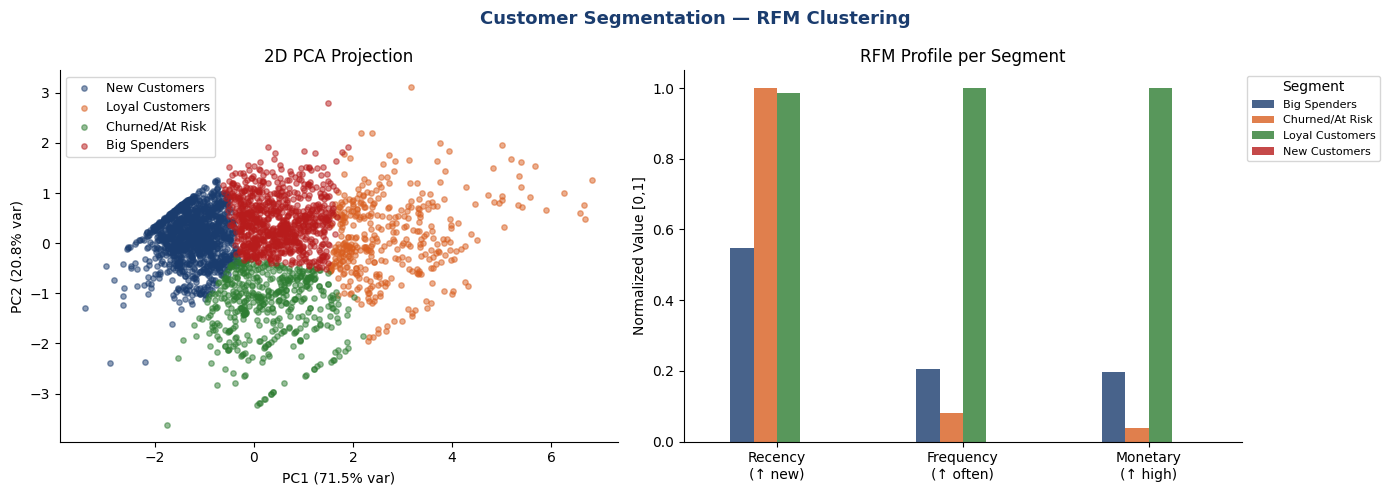

In [ ]:
# ════════════════════════════════════════════════════════
# LANGKAH 6: VISUALISASI
# ════════════════════════════════════════════════════════

# Scatter plot 3D melalui PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_pca = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segmentation — RFM Clustering',
             fontweight='bold', color='#1A3C6E', fontsize=13)

# Panel 1: PCA scatter
warna = ['#1A3C6E', '#D95F20', '#2E7D32', '#B71C1C']
for k, (label, grp) in enumerate(
    rfm.groupby('Klaster')[['Klaster']].apply(lambda x: x.index).items()
):
    mask = rfm['Klaster'] == k
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=warna[k], label=NAMA_KLASTER[k],
                    s=15, alpha=0.5)
axes[0].set_xlabel(f'PC1 ({var_pca[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({var_pca[1]:.1%} var)')
axes[0].set_title('2D PCA Projection')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Panel 2: Radar chart (profil RFM per segmen)
# Normalisasi ke [0,1] untuk radar chart
rfm_radar = rfm.groupby('Segmen')[['Recency','Frequency','Monetary']].mean()
rfm_radar['Recency'] = 1 - (rfm_radar['Recency'] - rfm_radar['Recency'].min()) / \
                           (rfm_radar['Recency'].max() - rfm_radar['Recency'].min())
for col in ['Frequency','Monetary']:
    rfm_radar[col] = (rfm_radar[col] - rfm_radar[col].min()) / \
                      (rfm_radar[col].max() - rfm_radar[col].min())
rfm_radar.T.plot(kind='bar', ax=axes[1], color=warna, alpha=0.8)
axes[1].set_xticklabels(['Recency\n(↑ new)', 'Frequency\n(↑ often)',
                          'Monetary\n(↑ high)'], rotation=0)
axes[1].set_ylabel('Normalized Value [0,1]')
axes[1].set_title('RFM Profile per Segment')
axes[1].legend(title='Segment', fontsize=8, bbox_to_anchor=(1, 1))
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()

# Create the 'output' directory if it doesn't exist
os.makedirs('output', exist_ok=True)
plt.savefig('output/segmentasi_rfm.pdf', bbox_inches='tight')
plt.show()



#### **Langkah 7: Rekomendasi Strategi per Segmen**

Langkah terakhir adalah menerjemahkan hasil segmentasi menjadi actionable insights:

1.  **Identifikasi Strategi**: Berdasarkan profil dan nama setiap klaster, rekomendasi strategi bisnis atau pemasaran yang disesuaikan diberikan. Misalnya, 'New Customers' mungkin membutuhkan *welcome offers*, sementara 'Loyal Customers' bisa ditargetkan dengan *loyalty programs*.
2.  **Ringkasan**: Output mencetak jumlah pelanggan dan persentase yang termasuk dalam setiap segmen, diikuti dengan saran strategi yang relevan untuk segmen tersebut. Ini membantu dalam mengimplementasikan kampanye yang terfokus dan efektif.

In [ ]:
# ════════════════════════════════════════════════════════
# LANGKAH 7: REKOMENDASI STRATEGI PER SEGMEN
# ════════════════════════════════════════════════════════
strategi = {
    'New Customers'    : 'Welcome offers, onboarding campaigns, encourage first repeat purchase',
    'Loyal Customers'  : 'Loyalty programs, exclusive offers, personalized recommendations, referral bonuses',
    'Churned/At Risk'  : 'Re-engagement campaigns, win-back offers, surveys to understand dissatisfaction',
    'Big Spenders'     : 'VIP treatment, premium products, dedicated support, exclusive events',
}
print('\n=== REKOMENDASI STRATEGI ===')
for segmen, saran in strategi.items():
    n = (rfm['Segmen']==segmen).sum()
    pct = n/len(rfm)*100
    print(f'\n{segmen} ({n:,} customers, {pct:.1f}%):')
    print(f'  → {saran}')


=== REKOMENDASI STRATEGI ===

New Customers (1,236 customers, 42.9%):
  → Welcome offers, onboarding campaigns, encourage first repeat purchase

Loyal Customers (388 customers, 13.5%):
  → Loyalty programs, exclusive offers, personalized recommendations, referral bonuses

Churned/At Risk (460 customers, 16.0%):
  → Re-engagement campaigns, win-back offers, surveys to understand dissatisfaction

Big Spenders (794 customers, 27.6%):
  → VIP treatment, premium products, dedicated support, exclusive events
